## Skill: Cell type annotation with scANVI

- For single slice gene modality, to annotate celltype
- Input: a scRNA reference with celltype column, a spatial adata
- output: append a celltype column to the spatial adata

- Should check: if the spatial adata min counts > 1 (have been cleaned up), if the user provide the reference path, if the celltype column is in the reference and loading the reference successfully, if the scvi package is successfully installed.
- Some note: if the number of gene in spatial < 1000, then use the intersection of spatial adata and reference gene. Otherwise: first take intersection of sc and st, then find the 1000 highly variable gene of the intersection gene in sc reference. Use it for annotate spatial data.

In [1]:
import scanpy as sc

In [4]:
# Apply to any anndata object
# Less than 1000 gene

session_adata_single_slice = sc.read_h5ad("/import/home3/yhchenmath/Code/spatialdata-agent-data-prepare/demo_data/single/bc_rep1/human_breast_cancer.h5ad")

In [ ]:
# Reference adata: with cell type annotation in celltype column
ref_adata = sc.read_h5ad("/import/home3/yhchenmath/Code/spatialdata-agent-data-prepare/demo_data/reference/bc.h5ad")

In [13]:
def annotation_scvi(adata_gene_single_slice, ref_adata, label_key='celltype'):

    import scvi
    import anndata as ad
    import warnings 
    warnings.filterwarnings("ignore")

    st_adata = adata_gene_single_slice.copy()
    sc_adata = ref_adata.copy()

    # Select common genes
    st_adata.var_names_make_unique()
    sc_adata.var_names_make_unique()
    common_genes = st_adata.var_names.intersection(sc_adata.var_names)
    st_adata = st_adata[:, common_genes]
    sc_adata = sc_adata[:, common_genes]
    
    # the preprocess of st is done in data prepare step
    # sc.pp.filter_cells(st_adata, min_counts=1)
    sc.pp.filter_cells(sc_adata, min_counts=1)

    st_adata.obs["tech"] = "st"
    sc_adata.obs["tech"] = "sc"
    scvi.settings.seed = 0
    print("Last run with scvi-tools version:", scvi.__version__)
    adata = ad.concat([sc_adata, st_adata])
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.raw = adata  # keep full dimension safe
    scvi.model.SCVI.setup_anndata(adata, batch_key="tech")
    scvi_model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)
    scvi_model.train()
    SCANVI_CELLTYPE_KEY = "celltype_scanvi"
    adata.obs[SCANVI_CELLTYPE_KEY] = "Unknown"
    sc_mask = adata.obs["tech"] == "sc"
    adata.obs[SCANVI_CELLTYPE_KEY][sc_mask] = sc_adata.obs[label_key][
        sc_mask
    ].values
    scanvi_model = scvi.model.SCANVI.from_scvi_model(
        scvi_model,
        adata=adata,
        unlabeled_category="Unknown",
        labels_key=SCANVI_CELLTYPE_KEY,
    )
    scanvi_model.train(max_epochs=20, n_samples_per_label=100)
    SCANVI_LATENT_KEY = "X_scANVI"
    SCANVI_PREDICTION_KEY = "C_scANVI"
    adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)
    adata.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata)
    annotated_adata_st = adata[adata.obs["tech"] == "st"]
    # Return the celltype column
    return annotated_adata_st.obs[SCANVI_PREDICTION_KEY]

annotation_results = annotation_scvi(session_adata_single_slice, ref_adata, label_key='celltype')
session_adata_single_slice.obs["celltype"] = annotation_results

Seed set to 0


Last run with scvi-tools version: 1.1.2


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 41/41: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [10:34<00:00, 15.04s/it, v_num=1, train_loss_step=185, train_loss_epoch=184]

`Trainer.fit` stopped: `max_epochs=41` reached.


Epoch 41/41: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [10:34<00:00, 15.47s/it, v_num=1, train_loss_step=185, train_loss_epoch=184]
INFO     Training for 20 epochs.                                                                                   


Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]


Epoch 20/20: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [13:24<00:00, 40.43s/it, v_num=1, train_loss_step=186, train_loss_epoch=191]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [13:24<00:00, 40.25s/it, v_num=1, train_loss_step=186, train_loss_epoch=191]


In [14]:
session_adata_single_slice.obs["celltype"]

cell_id
480          Invasive Tumor
481       Perivascular-Like
482          Invasive Tumor
483          Invasive Tumor
486                  DCIS 2
                ...        
166472    Perivascular-Like
166478        Macrophages 1
166479        Macrophages 1
166482          Endothelial
166484    Perivascular-Like
Name: celltype, Length: 167236, dtype: object

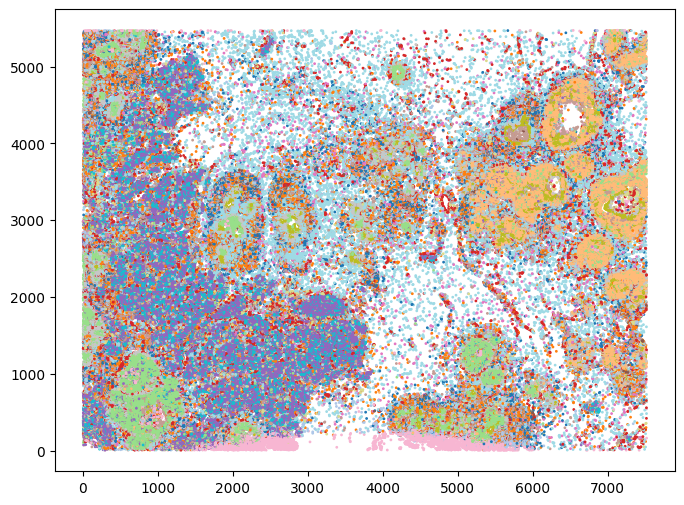

In [18]:
# Scatter plot
import matplotlib.pyplot as plt

x = session_adata_single_slice.obs['x']
y = session_adata_single_slice.obs['y']
celltypes = session_adata_single_slice.obs['celltype']

plt.figure(figsize=(8, 6))
scatter = plt.scatter(x, y, c=celltypes.astype('category').cat.codes, cmap='tab20', s=1)